# Temporal Test Set curated from PDB Bank

### PDB ID Collection
The pipeline requires a list of PDB IDs for the RNA-ligand complexes to be processed.
Based on requirements, here are thresholds set up for getting PDB ids using RCSB PDB Bank advanced search: https://www.rcsb.org/search/advanced.
1. Structure Attributes -> Number of Distinct RNA Entities >= 1
2. Structure Attributes -> Total Number of Non-polymer Instances >= 1

### Further Filtering
For those collected complexes. further filtering is applied based on following criteria:
1. The ligand must be a small molecule (less than 1000 Da and larger than 100 Da).
2. Filter the ligands that are solvent or metal ion.
3. The complexes only contain RNA and the ligand of interest without any protein or DNA chains.
4. The RNA sequences don't exist in the Hariboss training set.

### Motif annotation
For the final curated test set, motif annotation is performed based on the binding pocket in the range of 10 Å around the ligand using annotation from RNA 3D Hub: https://rna.bgsu.edu/rna3dhub/

### Summary
The final curated temporal test set results in 34 RNA-ligand complexes with diverse RNA 3D motifs and ligand types released ranging from 2025-01-22 to 2025-11-26 (throughout the year 2025). We further analyzed the sequence similarity and RNA structural similarity between the temporal test set and the Hariboss training set. More detailed visualization and analysis can be found in the following sections.

### Dataset Statistics

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

In [160]:
tem_pd = pd.read_csv('time_dependent_test_set.csv')
tem_pd.head()

,PDB ID,Ligand ID,Chain ID,Resnum,RNA sequence,SMILES
0,9LKU,GMP,X,101,GGCGUAUAUCCUUAAUGAUAUGGUUUAAGGGCAAUACAUAGAAACC...,c1nc2c(n1C3C(C(C(O3)CO)O)O)N=C(NC2=O)N
1,9LKW,GUN,X,101,GGCGUAUAUCCUUAAUGAUAUGGUUUAAGGGCAAUACAUAGAAACC...,c1[nH]c2c(n1)C(=O)NC(=N2)N
2,9LKC,GNG,A,102,GGGUUGUAUAAGCUCGUUAAUUUGGAAUGAGCGUAUCUACAGGCAA...,c1nc2c(n1C3CC(C(O3)CO)O)NC(=NC2=O)N
3,9LKF,GMP,A,101,GGGUUGUAUAAGCUCGUUAAUUUGGAAUGAGCGUAUCUACAGGCAA...,c1nc2c(n1C3C(C(C(O3)CO)O)O)N=C(NC2=O)N
4,9V4X,9QC,A,101,GGGUUGUAUAAGCUCGUUAAUUUGGAAUGAGCGUAUCUACAGGCAA...,c12c([nH]nn1)N=C(NC2=O)N


In [161]:
# obtain unique RNA sequence from the temporal test set and create dict for mapping RNA sequence to multiple ligands
tem_seq_dict = {}
for index, row in tem_pd.iterrows():
    rna_seq = row['RNA sequence']
    ligand_id = row['Ligand ID']
    if rna_seq not in tem_seq_dict:
        tem_seq_dict[rna_seq] = []
    tem_seq_dict[rna_seq].append(ligand_id)

tem_seq_dict = dict(sorted(tem_seq_dict.items(), key=lambda item: len(item[1]), reverse=True))
for rna_seq, ligands in tem_seq_dict.items():
    if len(ligands) >= 2:
        print(f'RNA Sequence: {rna_seq}, Number of Ligands: {len(ligands)}; Ligand IDs: {ligands}')

RNA Sequence: GGGUUGUAUAAGCUCGUUAAUUUGGAAUGAGCGUAUCUACAGGCAACCGUAAAUUGCCCCAGGCUACAAUC, Number of Ligands: 7; Ligand IDs: ['GNG', 'GMP', '9QC', 'ANG', 'NPR', 'GUN', 'A1LXN']
RNA Sequence: GGCGUAUAUCCUUAAUGAUAUGGUUUAAGGGCAAUACAUAGAAACCACAAAUUUCUUACUGCGUC, Number of Ligands: 2; Ligand IDs: ['GMP', 'GUN']
RNA Sequence: GGAUGAAAAAACACGAUUCGGUUGGUAGUCCGGAUGCCGAAAGGUCAGUAACCUUCCACGAAAGUGGAUGUCCAUCAUCCA, Number of Ligands: 2; Ligand IDs: ['CTI', 'LUM']
RNA Sequence: CGCUAGGGAUAAACUGUUUGUCCCUUUAUAUAGAGAUAUAUAGAAUAACAAUCGGGUGAAUUGCAAGAAUACCACCCACCUCCUUUGGAGGUGGGUGACAAUUUGCAGCGAAGUAUAUAUUAGCUUAAUAAUAAAAUAUUAUUUAGAUAUAUAAACGUUCAACGACUAGAAGGUGAGUAAGCUAACAAUAACCCUUCCACGAGCGCCCGACAUCUUAAUGAACCAACAAUUACAAUUAAUUAAAGGUCAUUAUGAUGAUGACAUAGUCUGAACUAAAUAGUGAUAUUUAGAUAUAAUAUUUAAAUGAUAUUAUGAUAACAAAAUUGAACAGG, Number of Ligands: 2; Ligand IDs: ['5GP', 'A1BNU']
RNA Sequence: GGAUUCGUAUAUCCUUAAUGAUAUGGUUUAAGGGCAAUACAUAGAGACCACAAAUUUCUUACUGCGAAUUCU, Number of Ligands: 2; Ligand IDs: ['GUN', 'GNG']


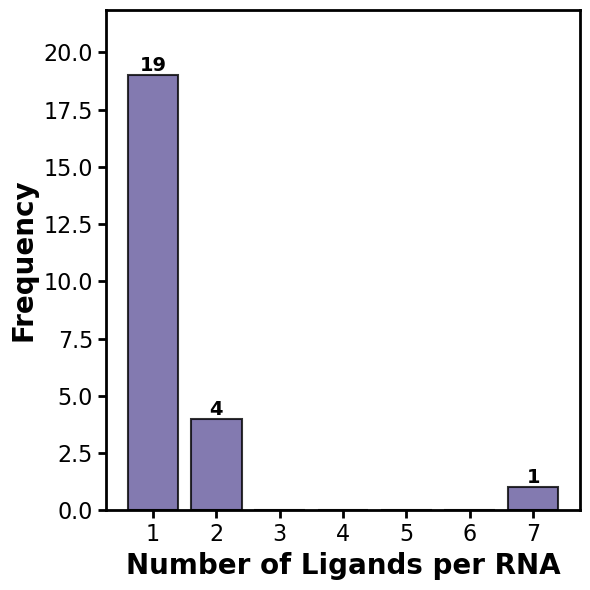

In [162]:
# draw histogram of number of ligands per RNA sequence
ligand_counts = [len(ligands) for ligands in tem_seq_dict.values()]
fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(range(1, max(ligand_counts)+1), 
              [ligand_counts.count(i) for i in range(1, max(ligand_counts)+1)], 
              width=0.8, color='#64599C', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_xlabel('Number of Ligands per RNA', fontsize=20, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=20, fontweight='bold')
# ax.set_title('Distribution of Ligands per RNA Sequence', fontsize=20, fontweight='bold')
ax.set_xticks(range(1, max(ligand_counts)+1))
ax.tick_params(axis='both', labelsize=16, width=2, length=6)
ax.set_ylim(0, max([ligand_counts.count(i) for i in range(1, max(ligand_counts)+1)]) * 1.15)

# Make spines bold
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('supplementary_figures/ligand_per_RNA.png', dpi=600, bbox_inches='tight')
plt.show()

In [163]:
# do it inverse: map ligand to RNA sequences
tem_ligand_dict = {}
for index, row in tem_pd.iterrows():
    rna_seq = row['RNA sequence']
    ligand_id = row['Ligand ID']
    if ligand_id not in tem_ligand_dict:
        tem_ligand_dict[ligand_id] = []
    tem_ligand_dict[ligand_id].append(rna_seq)
# sort by number of RNA sequences per ligand
tem_ligand_dict = dict(sorted(tem_ligand_dict.items(), key=lambda item: len(item[1]), reverse=True))
# print ligand with multiple RNA sequences >=2
for ligand_id, rnas in tem_ligand_dict.items():
    if len(rnas) >= 2:
        print(f'Ligand ID: {ligand_id}, Number of RNA Sequences: {len(rnas)}')

Ligand ID: 53D, Number of RNA Sequences: 5
Ligand ID: GUN, Number of RNA Sequences: 4
Ligand ID: GNG, Number of RNA Sequences: 4
Ligand ID: GMP, Number of RNA Sequences: 3
Ligand ID: XAN, Number of RNA Sequences: 2
Ligand ID: TAC, Number of RNA Sequences: 2


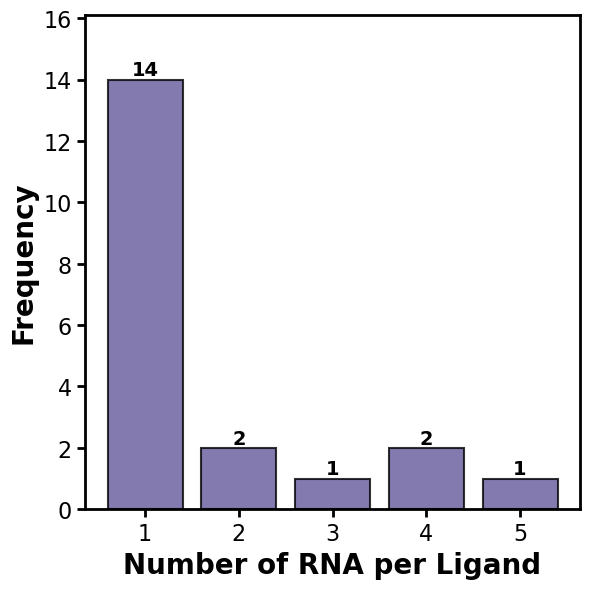

In [164]:
# draw histogram of number of RNA sequences per ligand
rna_counts = [len(rnas) for rnas in tem_ligand_dict.values()]
fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(range(1, max(rna_counts)+1), 
              [rna_counts.count(i) for i in range(1, max(rna_counts)+1)], 
              width=0.8, color='#64599C', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_xlabel('Number of RNA per Ligand', fontsize=20, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=20, fontweight='bold')
# ax.set_title('Distribution of RNA Sequences per Ligand in Temporal Test Set', fontsize=18, fontweight='bold')
ax.set_xticks(range(1, max(rna_counts)+1))
ax.tick_params(axis='both', labelsize=16, width=2, length=6)
ax.set_ylim(0, max([rna_counts.count(i) for i in range(1, max(rna_counts)+1)]) * 1.15)

# Make spines bold
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('supplementary_figures/RNA_per_ligand.png', dpi=600, bbox_inches='tight')
plt.show()

# RNA sequence similarity analysis
Only two PDBs 8T5O and 8SYK showing high sequence similarity to the Hariboss training dataset.

In [123]:
best_hits = pd.read_csv('verification_temporal_vs_train/temporal_vs_training_BEST_HITS.csv')
non_zero_bits = best_hits[best_hits['bits'] > 0]
non_zero_bits.head(10)

,Temporal_PDB,Temporal_Chain,query_id,target_id,Identity_Pct,Query_Coverage_Pct,alnlen,qlen,tlen,evalue,bits
19,8T5O,A,8T5O_A,3egz_B_D_CTC_601,96.7,25.0,31.0,124.0,65.0,1.507000e-08,53.0
33,8SYK,A,8SYK_A,3egz_B_D_CTC_601,96.7,29.0,31.0,107.0,65.0,1.195000e-08,53.0


# RNA structure similarity analysis  

## Investigate pocket similarity

In [124]:
with open('pocket_rmscore_matrix_avg.pkl', 'rb') as f:
    rmscore_matrix = pickle.load(f)

rmscore_matrix.keys()

dict_keys(['rmscore_matrix', 'pocket_names', 'pocket_files', 'n_pockets'])

In [125]:
print(rmscore_matrix['rmscore_matrix'][0][:5])
print(f'Shape: {rmscore_matrix["rmscore_matrix"].shape}')

[1.       0.788815 0.251645 0.376965 0.345505]
Shape: (1280, 1280)


In [126]:
print(rmscore_matrix['pocket_names'][:5])
print(len(rmscore_matrix['pocket_names']))

['1aju_ARG_A_pocket', '1akx_ARG_A_pocket', '1am0_AMP_A_pocket', '1arj_ARG_N_pocket', '1eht_TEP_A_pocket']
1280


In [127]:
temporal_pd = pd.read_csv('time_dependent_test_set.csv')
pocket_list = []
for i in range(len(temporal_pd)):
    pdbId = temporal_pd.iloc[i]['PDB ID'].lower()
    ligand_id = temporal_pd.iloc[i]['Ligand ID']
    chain_id = temporal_pd.iloc[i]['Chain ID']
    pocket_list.append(f'{pdbId}_{ligand_id}_{chain_id}_pocket')
for pocket in pocket_list:
    if pocket not in rmscore_matrix['pocket_names']:
        print(pocket)

In [128]:
# Extract pairwise similarity matrix for temporal set pockets vs all pockets
similarity_matrix = rmscore_matrix['rmscore_matrix']

temporal_indices = []
temporal_pocket_names = []
for pocket in pocket_list:
    if pocket in rmscore_matrix['pocket_names']:
        idx = rmscore_matrix['pocket_names'].index(pocket)
        temporal_indices.append(idx)
        temporal_pocket_names.append(pocket)
    else:
        print(f"Warning: {pocket} not found in similarity matrix")

print(f"Found {len(temporal_indices)} temporal set pockets in the similarity matrix")
print(f"Total pockets in similarity matrix: {len(rmscore_matrix['pocket_names'])}")

all_indices = set(range(len(rmscore_matrix['pocket_names'])))
temporal_set = set(temporal_indices)
non_temporal_indices = sorted(list(all_indices - temporal_set))

temporal_vs_all_matrix = similarity_matrix[np.ix_(temporal_indices, non_temporal_indices)]
print(f"\nExtracted matrix shape: {temporal_vs_all_matrix.shape}")
print(f"Shape interpretation: ({len(temporal_pocket_names)} temporal pockets) x ({len(non_temporal_indices)} all pockets)")

print(f"\nFirst 5 temporal pockets:")
for i, pocket in enumerate(temporal_pocket_names[:5]):
    print(f"  {i}: {pocket}")

Found 34 temporal set pockets in the similarity matrix
Total pockets in similarity matrix: 1280

Extracted matrix shape: (34, 1246)
Shape interpretation: (34 temporal pockets) x (1246 all pockets)

First 5 temporal pockets:
  0: 9lku_GMP_X_pocket
  1: 9lkw_GUN_X_pocket
  2: 9lkc_GNG_A_pocket
  3: 9lkf_GMP_A_pocket
  4: 9v4x_9QC_A_pocket


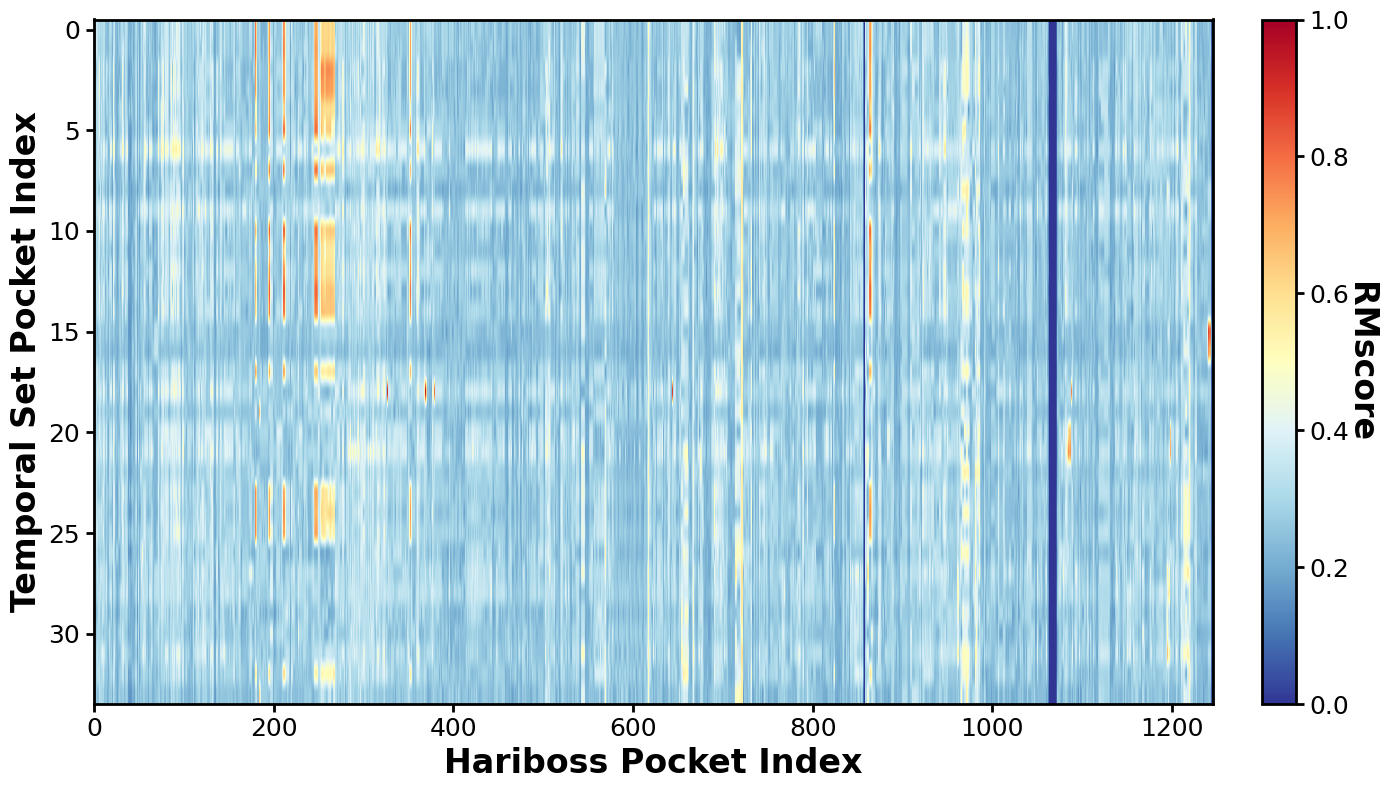

In [129]:
# Visualize the temporal vs all pockets similarity matrix
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(temporal_vs_all_matrix, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')

# Add colorbar with better styling
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('RMscore', fontsize=24, fontweight='bold', rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=18, width=2, length=6)
for spine in cbar.ax.spines.values():
    spine.set_linewidth(2)

# ax.set_title('Temporal Set Pockets vs Hariboss Pockets RMscore Matrix',
            # fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Hariboss Pocket Index', fontsize=24, fontweight='bold')
ax.set_ylabel('Temporal Set Pocket Index', fontsize=24, fontweight='bold')
ax.tick_params(axis='both', labelsize=18, width=2, length=6)

# Make spines bold
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('supplementary_figures/pocket_pairwise_matrix.png', dpi=600, bbox_inches='tight')
plt.show()

In [130]:
# For each temporal pocket, find the most similar pockets
print("Top 5 most similar pockets for each temporal set pocket:\n")
for i, temporal_pocket in enumerate(temporal_pocket_names):
    similarities = temporal_vs_all_matrix[i, :]
    
    sorted_indices = np.argsort(similarities)[::-1]
    
    print(f"\n{temporal_pocket}:")
    count = 0
    for idx in sorted_indices:
        target_pocket = rmscore_matrix['pocket_names'][idx]
        score = similarities[idx]
        
        if target_pocket == temporal_pocket:
            print(f"  Self-similarity: {score:.4f}")
            continue
            
        print(f"  {count+1}. {target_pocket}: {score:.4f}")
        count += 1
        if count >= 5:
            break


Top 5 most similar pockets for each temporal set pocket:


9lku_GMP_X_pocket:
  1. 3ds7_GNG_A_pocket: 0.7985
  2. 3ger_6GU_A_pocket: 0.7479
  3. 6uc8_ANG_B_pocket: 0.7458
  4. 3gog_6GU_A_pocket: 0.7388
  5. 3fo4_6GU_A_pocket: 0.7382

9lkw_GUN_X_pocket:
  1. 3ds7_GNG_A_pocket: 0.8078
  2. 3ger_6GU_A_pocket: 0.7721
  3. 6uc8_ANG_B_pocket: 0.7667
  4. 3fo4_6GU_A_pocket: 0.7641
  5. 3gog_6GU_A_pocket: 0.7587

9lkc_GNG_A_pocket:
  1. 6p2h_GNG_A_pocket: 0.7924
  2. 3ski_GNG_A_pocket: 0.7728
  3. 3ski_GNG_B_pocket: 0.7728
  4. 3skw_GNG_B_pocket: 0.7551
  5. 3skw_GNG_A_pocket: 0.7551

9lkf_GMP_A_pocket:
  1. 6p2h_GNG_A_pocket: 0.7622
  2. 3ds7_GNG_A_pocket: 0.7441
  3. 3ski_GNG_B_pocket: 0.7354
  4. 3ski_GNG_A_pocket: 0.7354
  5. 3ger_6GU_A_pocket: 0.7338

9v4x_9QC_A_pocket:
  1. 3fo4_6GU_A_pocket: 0.7466
  2. 3rkf_DX4_D_pocket: 0.7435
  3. 3rkf_DX4_C_pocket: 0.7435
  4. 3rkf_DX4_A_pocket: 0.7435
  5. 3rkf_DX4_B_pocket: 0.7435

9v4y_ANG_A_pocket:
  1. 3rkf_DX4_D_pocket: 0.7986
  2. 3rkf_DX4_C_

Statistical Summary of Maximum Similarities (excluding self):
  Mean: 0.7313
  Median: 0.7586
  Min: 0.5450
  Max: 0.9647
  Std: 0.1065


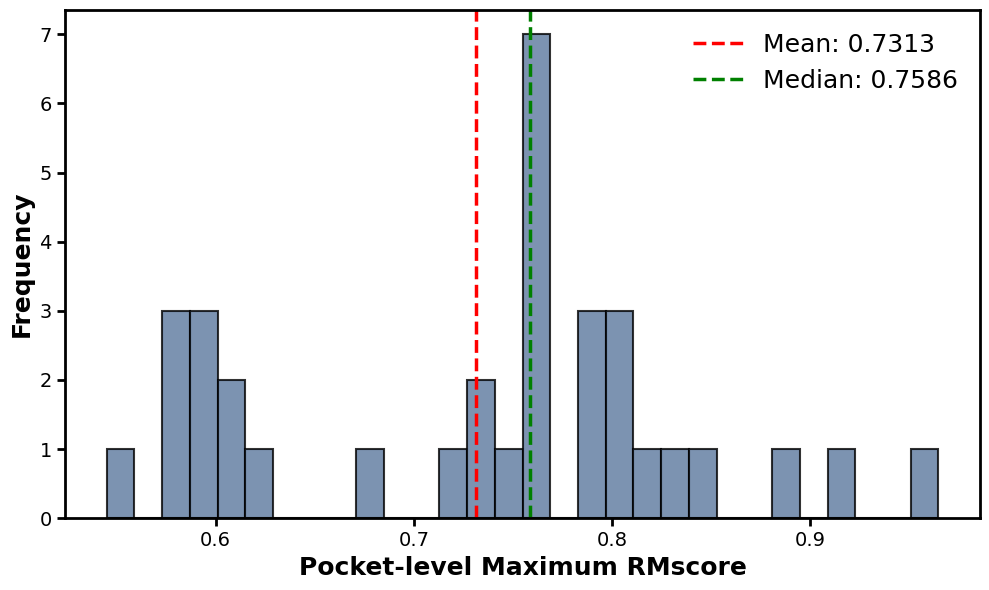

In [131]:
# Statistical analysis of similarity scores
max_similarities = []
for i in range(len(temporal_pocket_names)):
    similarities = temporal_vs_all_matrix[i, :].copy()
    max_sim = np.max(similarities)
    max_similarities.append(max_sim)

max_similarities = np.array(max_similarities)

print("Statistical Summary of Maximum Similarities (excluding self):")
print(f"  Mean: {np.mean(max_similarities):.4f}")
print(f"  Median: {np.median(max_similarities):.4f}")
print(f"  Min: {np.min(max_similarities):.4f}")
print(f"  Max: {np.max(max_similarities):.4f}")
print(f"  Std: {np.std(max_similarities):.4f}")

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(max_similarities, bins=30, color='#5B789E', alpha=0.8, 
                            edgecolor='black', linewidth=1.5)

ax.set_xlabel('Pocket-level Maximum RMscore', fontsize=18, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=18, fontweight='bold')
# ax.set_title('Distribution of Maximum Similarity Scores\nfor Temporal Set Chains vs All Chains', 
#              fontsize=18, fontweight='bold')

# Add mean and median lines
ax.axvline(np.mean(max_similarities), color='red', linestyle='--', linewidth=2.5, 
           label=f'Mean: {np.mean(max_similarities):.4f}')
ax.axvline(np.median(max_similarities), color='green', linestyle='--', linewidth=2.5, 
           label=f'Median: {np.median(max_similarities):.4f}')

ax.legend(fontsize=18, frameon=False, loc='upper right')
ax.tick_params(axis='both', labelsize=14, width=2, length=6)

# Make spines bold
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('supplementary_figures/pocket_sim_by_threshold.png', dpi=600, bbox_inches='tight')
plt.show()

In [132]:
# Save the extracted matrix for future use
temporal_vs_all_data = {
    'similarity_matrix': temporal_vs_all_matrix,
    'temporal_pocket_names': temporal_pocket_names,
    'all_pocket_names': rmscore_matrix['pocket_names'],
    'temporal_indices': temporal_indices,
    'max_similarities': max_similarities
}

# # Save as pickle file
# with open('temporal_vs_all_similarity_matrix.pkl', 'wb') as f:
#     pickle.dump(temporal_vs_all_data, f)

print("Saved temporal vs all pockets similarity matrix to 'temporal_vs_all_similarity_matrix.pkl'")
print(f"\nContents:")
print(f"  - similarity_matrix: shape {temporal_vs_all_matrix.shape}")
print(f"  - temporal_pocket_names: {len(temporal_pocket_names)} pockets")
print(f"  - all_pocket_names: {len(rmscore_matrix['pocket_names'])} pockets")
print(f"  - max_similarities: max similarity for each temporal pocket")

Saved temporal vs all pockets similarity matrix to 'temporal_vs_all_similarity_matrix.pkl'

Contents:
  - similarity_matrix: shape (34, 1246)
  - temporal_pocket_names: 34 pockets
  - all_pocket_names: 1280 pockets
  - max_similarities: max similarity for each temporal pocket


In [133]:
non_temporal_pocket_names = [rmscore_matrix['pocket_names'][i] for i in non_temporal_indices]

similarity_df = pd.DataFrame(
    temporal_vs_all_matrix,
    index=temporal_pocket_names,
    columns=non_temporal_pocket_names
)

print("Similarity DataFrame shape:", similarity_df.shape)
print("\nFirst 5x5 preview:")
similarity_df.iloc[:5, :5]

Similarity DataFrame shape: (34, 1246)

First 5x5 preview:


,1aju_ARG_A_pocket,1akx_ARG_A_pocket,1am0_AMP_A_pocket,1arj_ARG_N_pocket,1eht_TEP_A_pocket
9lku_GMP_X_pocket,0.278690,0.239510,0.349795,0.411380,0.271970
9lkw_GUN_X_pocket,0.278555,0.226815,0.359755,0.411830,0.257250
9lkc_GNG_A_pocket,0.361660,0.335800,0.241365,0.367945,0.264755
9lkf_GMP_A_pocket,0.367520,0.319725,0.311300,0.387160,0.292410
9v4x_9QC_A_pocket,0.356675,0.332485,0.304090,0.358865,0.279290


In [134]:
os.makedirs('structure_analysis', exist_ok=True)
similarity_df.to_csv('structure_analysis/pocket_temporal_vs_all_similarity_matrix.csv')

In [135]:
all_pocket_names = rmscore_matrix['pocket_names']
non_temporal_pocket_names = [all_pocket_names[i] for i in non_temporal_indices]

records = []

for i, query_pocket in enumerate(temporal_pocket_names):
    sims = temporal_vs_all_matrix[i]
    
    max_idx = np.argmax(sims)
    max_score = sims[max_idx]
    best_match_pocket = non_temporal_pocket_names[max_idx]
    
    records.append({
        "query_pocket": query_pocket,
        "best_match_pocket": best_match_pocket,
        "max_rmscore": float(max_score)
    })

nearest_df = pd.DataFrame(records)

print("Nearest-neighbor summary:")
print(nearest_df.head())

print("\nStatistics:")
print(nearest_df["max_rmscore"].describe())

# save the nearest neighbor summary
nearest_df.to_csv('structure_analysis/pocket_temporal_vs_all_nearest_neighbor_summary.csv')

Nearest-neighbor summary:
        query_pocket  best_match_pocket  max_rmscore
0  9lku_GMP_X_pocket  3ds7_GNG_A_pocket     0.798545
1  9lkw_GUN_X_pocket  3ds7_GNG_A_pocket     0.807770
2  9lkc_GNG_A_pocket  6p2h_GNG_A_pocket     0.792410
3  9lkf_GMP_A_pocket  6p2h_GNG_A_pocket     0.762225
4  9v4x_9QC_A_pocket  3fo4_6GU_A_pocket     0.746590

Statistics:
count    34.000000
mean      0.731287
std       0.108150
min       0.545010
25%       0.608586
50%       0.758642
75%       0.797075
max       0.964740
Name: max_rmscore, dtype: float64


In [136]:
# obtain query pocket PDB id with rmscore < 0.75
query_pocket_list = nearest_df[nearest_df['max_rmscore'] < 0.75]['query_pocket']

In [137]:
query_pocket_list

4       9v4x_9QC_A_pocket
6       9hro_TOY_A_pocket
8     9i9w_B2R_AAA_pocket
9       8znq_NAZ_A_pocket
11      9ljn_GUN_A_pocket
17      9lkv_GNG_X_pocket
20      9mqs_5GP_A_pocket
22      8zau_GUN_A_pocket
26      9fn2_SAH_A_pocket
27      9ios_53D_A_pocket
28      9io1_53D_A_pocket
29      9ior_53D_A_pocket
30      9iou_53D_A_pocket
31      9io0_53D_A_pocket
32      8z8q_GNG_A_pocket
Name: query_pocket, dtype: object

## Investigate chain similarity

In [138]:
with open('chain_rmscore_matrix_avg.pkl', 'rb') as f:
    rmscore_matrix = pickle.load(f)

rmscore_matrix.keys()

dict_keys(['rmscore_matrix', 'pocket_names', 'pocket_files', 'n_pockets'])

In [139]:
temporal_pd = pd.read_csv('time_dependent_test_set.csv')
pocket_list = []
for i in range(len(temporal_pd)):
    pdbId = temporal_pd.iloc[i]['PDB ID'].lower()
    ligand_id = temporal_pd.iloc[i]['Ligand ID']
    chain_id = temporal_pd.iloc[i]['Chain ID']
    pocket_list.append(f'{pdbId}_{chain_id}')
for pocket in pocket_list:
    if pocket not in rmscore_matrix['pocket_names']:
        print(pocket)

In [140]:
# Extract pairwise similarity matrix for temporal set pockets vs all pockets
similarity_matrix = rmscore_matrix['rmscore_matrix']

temporal_indices = []
temporal_pocket_names = []
for pocket in pocket_list:
    if pocket in rmscore_matrix['pocket_names']:
        idx = rmscore_matrix['pocket_names'].index(pocket)
        temporal_indices.append(idx)
        temporal_pocket_names.append(pocket)
    else:
        print(f"Warning: {pocket} not found in similarity matrix")

print(f"Found {len(temporal_indices)} temporal set chains in the similarity matrix")
print(f"Total chains in similarity matrix: {len(rmscore_matrix['pocket_names'])}")

all_indices = set(range(len(rmscore_matrix['pocket_names'])))
temporal_set = set(temporal_indices)
non_temporal_indices = sorted(list(all_indices - temporal_set))

temporal_vs_all_matrix = similarity_matrix[np.ix_(temporal_indices, non_temporal_indices)]

print(f"\nExtracted matrix shape: {temporal_vs_all_matrix.shape}")
print(f"Shape interpretation: ({len(temporal_pocket_names)} temporal Chains) x ({len(non_temporal_indices)} all Chains)")

print(f"\nFirst 5 temporal Chains:")
for i, pocket in enumerate(temporal_pocket_names[:5]):
    print(f"  {i}: {pocket}")

Found 34 temporal set chains in the similarity matrix
Total chains in similarity matrix: 1226

Extracted matrix shape: (34, 1192)
Shape interpretation: (34 temporal Chains) x (1192 all Chains)

First 5 temporal Chains:
  0: 9lku_X
  1: 9lkw_X
  2: 9lkc_A
  3: 9lkf_A
  4: 9v4x_A


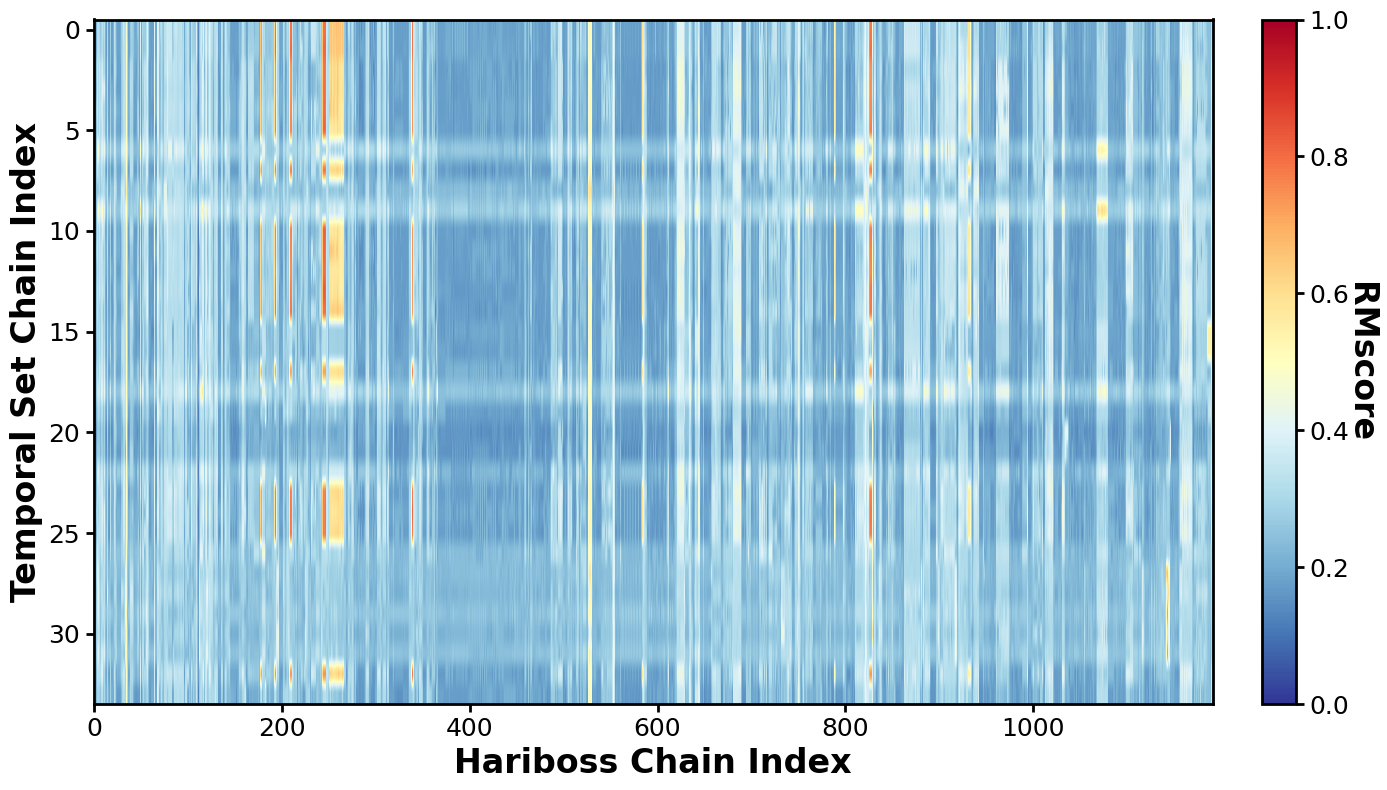

In [141]:
# Visualize the temporal vs all pockets similarity matrix
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(temporal_vs_all_matrix, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')

# Add colorbar with better styling
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('RMscore', fontsize=24, fontweight='bold', rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=18, width=2, length=6)
for spine in cbar.ax.spines.values():
    spine.set_linewidth(2)

# ax.set_title('Temporal Set Chains vs All Chains RMscore Matrix',
#             fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Hariboss Chain Index', fontsize=24, fontweight='bold')
ax.set_ylabel('Temporal Set Chain Index', fontsize=24, fontweight='bold')
ax.tick_params(axis='both', labelsize=18, width=2, length=6)

# Make spines bold
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('supplementary_figures/chain_pairwise_matrix.png', dpi=600, bbox_inches='tight')
plt.show()

In [142]:
# For each temporal pocket, find the most similar pockets (excluding itself)
print("Top 5 most similar chains for each temporal set chain:\n")
for i, temporal_pocket in enumerate(temporal_pocket_names):
    similarities = temporal_vs_all_matrix[i, :]
    
    sorted_indices = np.argsort(similarities)[::-1]
    
    print(f"\n{temporal_pocket}:")
    count = 0
    for idx in sorted_indices:
        target_pocket = rmscore_matrix['pocket_names'][idx]
        score = similarities[idx]
        
        if target_pocket == temporal_pocket:
            print(f"  Self-similarity: {score:.4f}")
            continue
            
        print(f"  {count+1}. {target_pocket}: {score:.4f}")
        count += 1
        if count >= 5:
            break

Top 5 most similar chains for each temporal set chain:


9lku_X:
  1. 3fo4_A: 0.8068
  2. 3rkf_D: 0.7981
  3. 3rkf_A: 0.7965
  4. 3rkf_B: 0.7928
  5. 3rkf_C: 0.7926

9lkw_X:
  1. 3fo4_A: 0.8225
  2. 3rkf_D: 0.8159
  3. 3rkf_A: 0.8146
  4. 3rkf_B: 0.8084
  5. 3rkf_C: 0.8065

9lkc_A:
  1. 3rkf_C: 0.7944
  2. 3rkf_B: 0.7907
  3. 6p2h_A: 0.7811
  4. 3rkf_D: 0.7772
  5. 3rkf_A: 0.7743

9lkf_A:
  1. 3rkf_C: 0.7992
  2. 3rkf_B: 0.7972
  3. 3rkf_D: 0.7857
  4. 6p2h_A: 0.7852
  5. 3rkf_A: 0.7833

9v4x_A:
  1. 3rkf_C: 0.8043
  2. 3rkf_B: 0.7995
  3. 3rkf_D: 0.7836
  4. 3rkf_A: 0.7815
  5. 6p2h_A: 0.7606

9v4y_A:
  1. 3rkf_C: 0.8138
  2. 3rkf_B: 0.8110
  3. 3rkf_D: 0.8010
  4. 3rkf_A: 0.7963
  5. 6uc9_B: 0.7767

9hro_A:
  1. 8d2b_B: 0.5349
  2. 8d5l_A: 0.5348
  3. 8d28_B: 0.5347
  4. 8d2a_A: 0.5336
  5. 8d2a_B: 0.5284

9iwf_A:
  1. 3rkf_B: 0.7806
  2. 3rkf_C: 0.7794
  3. 3rkf_D: 0.7762
  4. 3rkf_A: 0.7740
  5. 3gog_A: 0.7729

9i9w_AAA:
  1. 5dhb_A: 0.6256
  2. 5dhb_D: 0.6221
  3. 6u89_A: 0.6183
 

Statistical Summary of Maximum Similarities (excluding self):
  Mean: 0.6962
  Median: 0.7516
  Min: 0.5000
  Max: 0.8324
  Std: 0.1162


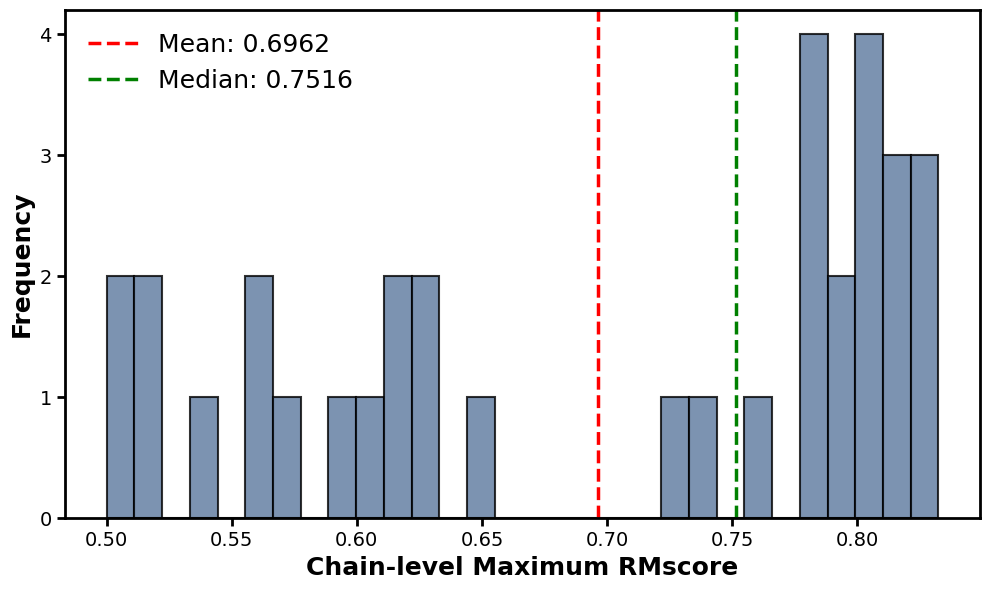

In [166]:
# Statistical analysis of similarity scores
max_similarities = []
for i in range(len(temporal_pocket_names)):
    similarities = temporal_vs_all_matrix[i, :].copy()
    max_sim = np.max(similarities)
    max_similarities.append(max_sim)

max_similarities = np.array(max_similarities)

print("Statistical Summary of Maximum Similarities (excluding self):")
print(f"  Mean: {np.mean(max_similarities):.4f}")
print(f"  Median: {np.median(max_similarities):.4f}")
print(f"  Min: {np.min(max_similarities):.4f}")
print(f"  Max: {np.max(max_similarities):.4f}")
print(f"  Std: {np.std(max_similarities):.4f}")

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(max_similarities, bins=30, color='#5B789E', alpha=0.8, 
                            edgecolor='black', linewidth=1.5)

ax.set_xlabel('Chain-level Maximum RMscore', fontsize=18, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=18, fontweight='bold')
# ax.set_title('Distribution of Maximum Similarity Scores\nfor Temporal Set Chains vs All Chains', 
#              fontsize=18, fontweight='bold')

# Add mean and median lines
ax.axvline(np.mean(max_similarities), color='red', linestyle='--', linewidth=2.5, 
           label=f'Mean: {np.mean(max_similarities):.4f}')
ax.axvline(np.median(max_similarities), color='green', linestyle='--', linewidth=2.5, 
           label=f'Median: {np.median(max_similarities):.4f}')

ax.legend(fontsize=18, frameon=False, loc='upper left')
ax.tick_params(axis='both', labelsize=14, width=2, length=6)

# Set y-axis to only show integer values
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Make spines bold
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('supplementary_figures/chain_sim_by_threshold.png', dpi=600, bbox_inches='tight')
plt.show()

In [144]:
# Save the extracted matrix for future use
temporal_vs_all_data = {
    'similarity_matrix': temporal_vs_all_matrix,
    'temporal_pocket_names': temporal_pocket_names,
    'all_pocket_names': rmscore_matrix['pocket_names'],
    'temporal_indices': temporal_indices,
    'max_similarities': max_similarities
}

print(f"\nContents:")
print(f"  - similarity_matrix: shape {temporal_vs_all_matrix.shape}")
print(f"  - temporal_chain_names: {len(temporal_pocket_names)} chains")
print(f"  - all_chain_names: {len(rmscore_matrix['pocket_names'])} chains")
print(f"  - max_similarities: max similarity for each temporal chain")


Contents:
  - similarity_matrix: shape (34, 1192)
  - temporal_chain_names: 34 chains
  - all_chain_names: 1226 chains
  - max_similarities: max similarity for each temporal chain


In [145]:
non_temporal_pocket_names = [rmscore_matrix['pocket_names'][i] for i in non_temporal_indices]

similarity_df = pd.DataFrame(
    temporal_vs_all_matrix,
    index=temporal_pocket_names,
    columns=non_temporal_pocket_names
)

print("Similarity DataFrame shape:", similarity_df.shape)
print("\nFirst 5x5 preview:")
similarity_df.iloc[:5, :5]

Similarity DataFrame shape: (34, 1192)

First 5x5 preview:


,1aju_A,1akx_A,1am0_A,1arj_N,1eht_A
9lku_X,0.390715,0.408970,0.202590,0.321365,0.333805
9lkw_X,0.388610,0.406635,0.197660,0.320945,0.336910
9lkc_A,0.343365,0.306745,0.230755,0.376955,0.292470
9lkf_A,0.342400,0.328955,0.202090,0.374745,0.306195
9v4x_A,0.358055,0.335310,0.250490,0.382070,0.293275


In [146]:
os.makedirs('structure_analysis', exist_ok=True)
similarity_df.to_csv('structure_analysis/chain_temporal_vs_all_similarity_matrix.csv')

In [147]:
all_pocket_names = rmscore_matrix['pocket_names']
non_temporal_pocket_names = [all_pocket_names[i] for i in non_temporal_indices]

records = []

for i, query_pocket in enumerate(temporal_pocket_names):
    sims = temporal_vs_all_matrix[i]
    
    max_idx = np.argmax(sims)
    max_score = sims[max_idx]
    best_match_pocket = non_temporal_pocket_names[max_idx]
    
    records.append({
        "query_pocket": query_pocket,
        "best_match_pocket": best_match_pocket,
        "max_rmscore": float(max_score)
    })

nearest_df = pd.DataFrame(records)

print("Nearest-neighbor summary:")
print(nearest_df.head())

print("\nStatistics:")
print(nearest_df["max_rmscore"].describe())

# save the nearest neighbor summary
nearest_df.to_csv('structure_analysis/chain_temporal_vs_all_nearest_neighbor_summary.csv')

Nearest-neighbor summary:
  query_pocket best_match_pocket  max_rmscore
0       9lku_X            3fo4_A     0.806830
1       9lkw_X            3fo4_A     0.822480
2       9lkc_A            3rkf_C     0.794440
3       9lkf_A            3rkf_C     0.799190
4       9v4x_A            3rkf_C     0.804315

Statistics:
count    34.000000
mean      0.696209
std       0.117922
min       0.499995
25%       0.595378
50%       0.751565
75%       0.802509
max       0.832420
Name: max_rmscore, dtype: float64


In [148]:
query_chain_list = nearest_df[nearest_df['max_rmscore'] < 0.75]['query_pocket']

In [149]:
query_pocket_id_list = [pocket.split('_')[0] for pocket in query_chain_list]
query_chain_id_list = [pocket.split('_')[0] for pocket in query_chain_list]

In [150]:
joint_exist_id_list = [id for id in query_pocket_id_list if id in query_chain_id_list]
print(len(joint_exist_id_list))

17


In [151]:
joint_exist_id_list = [id for id in joint_exist_id_list if id not in ['8t5o', '8syk']]

In [152]:
joint_exist_id_list

['9hro',
 '9i9w',
 '8znq',
 '9ec4',
 '9ebp',
 '8k7w',
 '9mqs',
 '9mqt',
 '8zau',
 '9fn2',
 '9ios',
 '9io1',
 '9ior',
 '9iou',
 '9io0']

#### Check ligand overlap

In [153]:
with open('/blue/yanjun.li/sjiang43.johnshopkins/pub_version/v3_1119/SMARTBind-internal/revision/data/data/hariboss_merged_5fd_with_decoys.pkl', 'rb') as f:
    hariboss_data = pickle.load(f)
    
ligand_id_list = []
for k, v in hariboss_data.items():
    for k2, v2 in v.items():
        ligand_id_list.append(v2['ligand_id'])
ligand_id_list = list(set(ligand_id_list))

In [154]:
temporal_pd.head()

,PDB ID,Ligand ID,Chain ID,Resnum,RNA sequence,SMILES
0,9LKU,GMP,X,101,GGCGUAUAUCCUUAAUGAUAUGGUUUAAGGGCAAUACAUAGAAACC...,c1nc2c(n1C3C(C(C(O3)CO)O)O)N=C(NC2=O)N
1,9LKW,GUN,X,101,GGCGUAUAUCCUUAAUGAUAUGGUUUAAGGGCAAUACAUAGAAACC...,c1[nH]c2c(n1)C(=O)NC(=N2)N
2,9LKC,GNG,A,102,GGGUUGUAUAAGCUCGUUAAUUUGGAAUGAGCGUAUCUACAGGCAA...,c1nc2c(n1C3CC(C(O3)CO)O)NC(=NC2=O)N
3,9LKF,GMP,A,101,GGGUUGUAUAAGCUCGUUAAUUUGGAAUGAGCGUAUCUACAGGCAA...,c1nc2c(n1C3C(C(C(O3)CO)O)O)N=C(NC2=O)N
4,9V4X,9QC,A,101,GGGUUGUAUAAGCUCGUUAAUUUGGAAUGAGCGUAUCUACAGGCAA...,c12c([nH]nn1)N=C(NC2=O)N


In [155]:
for i in range(len(temporal_pd)):
    ligand_id = temporal_pd.iloc[i]['Ligand ID']
    pdb_id = temporal_pd.iloc[i]['PDB ID'].lower()
    # if ligand_id not in ligand_id_list and pdb_id in joint_exist_id_list:
    if ligand_id not in ligand_id_list:
        print(f"Warning: Ligand ID {ligand_id} and PDB ID {pdb_id} not found in Hariboss data or joint exist list")

#### 3D motif distribution & RNA type distribution

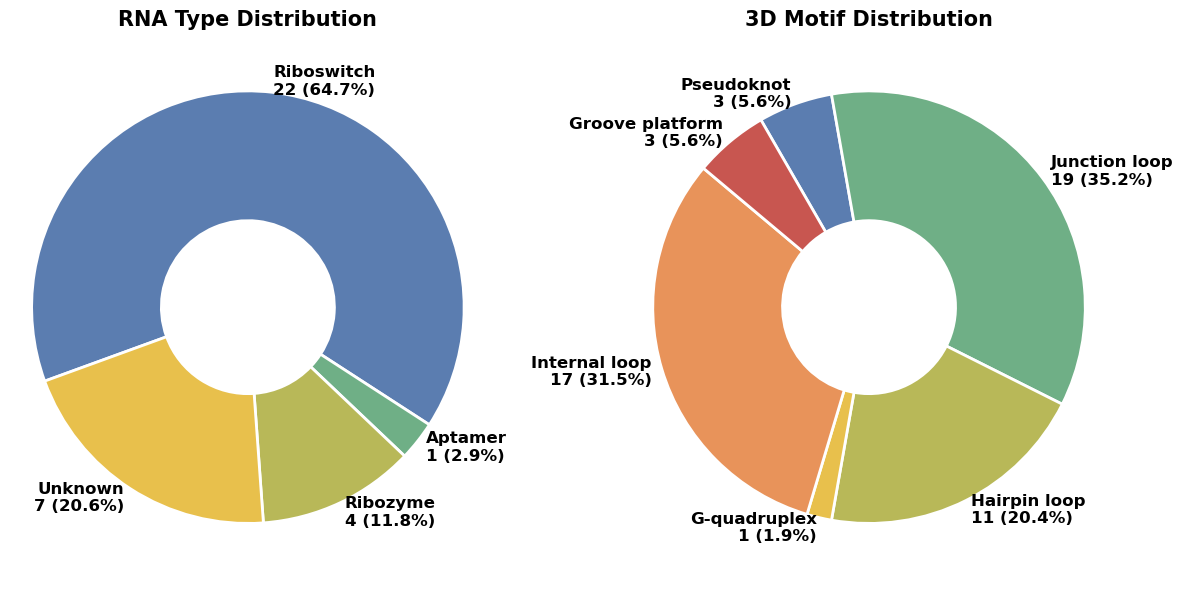

In [156]:
# Donut-style pie charts matching the provided figure style

import matplotlib.pyplot as plt
from collections import Counter

rna_types = [
"riboswitch","aptamer","riboswitch","riboswitch","riboswitch","riboswitch","ribozyme",
"riboswitch","unknown","unknown","unknown","unknown","unknown","ribozyme","ribozyme",
"ribozyme","riboswitch","riboswitch","riboswitch","riboswitch","riboswitch","riboswitch",
"riboswitch","riboswitch","riboswitch","riboswitch","riboswitch","unknown","unknown",
"riboswitch","riboswitch","riboswitch","riboswitch","riboswitch"
]

motifs = [
  "Pseudoknot", "Junction loop", "Hairpin loop",
  "G-quadruplex", "Internal loop",
  "Pseudoknot", "Junction loop", "Hairpin loop",
  "Pseudoknot", "Junction loop", "Hairpin loop",
  "Hairpin loop",
  "Hairpin loop",
  "Junction loop", "Internal loop",
  "Hairpin loop", "Junction loop",
  "Internal loop",
  "Internal loop",
  "Internal loop",
  "Internal loop",
  "Internal loop",
  "Groove platform",
  "Groove platform",
  "Groove platform", "Junction loop",
  "Junction loop",
  "Junction loop",
  "Internal loop", "Junction loop",
  "Internal loop", "Junction loop",
  "Internal loop", "Junction loop",
  "Internal loop", "Junction loop",
  "Internal loop", "Junction loop",
  "Internal loop", "Junction loop",
  "Junction loop",
  "Internal loop",
  "Hairpin loop", "Junction loop",
  "Internal loop",
  "Internal loop",
  "Internal loop", "Junction loop",
  "Hairpin loop", "Junction loop",
  "Hairpin loop",
  "Hairpin loop",
  "Hairpin loop", "Junction loop"
]

rna_counts = Counter(rna_types)
motif_counts = Counter(motifs)

colors = ['#5B7DB0', '#6FAF86', '#B8B858', '#E8C04C', '#E8935A', '#C85650', '#A8585C', '#9B7BA8', '#7BA8C8', '#D88888']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# RNA type donut chart (left)
rna_categories = list(rna_counts.keys())
rna_values = list(rna_counts.values())
total_rna = sum(rna_values)

# Create labels with category name, count and percentage
rna_labels = [f'{cat.capitalize()}\n{count} ({count/total_rna*100:.1f}%)' 
              for cat, count in zip(rna_categories, rna_values)]

# Create donut chart
wedges1, texts1 = ax1.pie(
    rna_values,
    labels=rna_labels,
    colors=colors[:len(rna_categories)],
    startangle=200,
    counterclock=False,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=12, weight='bold'),
    labeldistance=1.05
)

ax1.set_title('RNA Type Distribution', fontsize=15, weight='bold')
ax1.axis('equal')

# 3D motif donut chart (right)
motif_categories = list(motif_counts.keys())
motif_values = list(motif_counts.values())
total_motif = sum(motif_values)

# Create labels with category name, count and percentage
motif_labels = [f'{cat}\n{count} ({count/total_motif*100:.1f}%)' 
                for cat, count in zip(motif_categories, motif_values)]

# Create donut chart
wedges2, texts2 = ax2.pie(
    motif_values,
    labels=motif_labels,
    colors=colors[:len(motif_categories)],
    startangle=120,
    counterclock=False,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=12, weight='bold'),
    labeldistance=1.05
)

ax2.set_title('3D Motif Distribution', fontsize=15, weight='bold')
ax2.axis('equal')

plt.tight_layout()
plt.savefig('supplementary_figures/rna_motif_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
